# [LAB-07] 11. 다중 공선성 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## 문제 1

카페 프랜차이즈 본사 데이터 분석팀

### 1. 데이터 가져오기

In [2]:
df1 = load_data("bean_there")
df1.head()

📚 BeanThere 프랜차이즈 200개 직영점의 매장 특성 데이터


,면적_평,면적_m2,좌석수,직원수,일평균_방문객수,일평균_주문건수,지하철역_거리_m,월광고비_만원
0,27.100,89.900,43.000,7.000,365.000,310.000,162.000,221.000
1,17.700,59.700,29.000,4.000,233.000,193.000,312.000,131.000
2,30.300,100.100,51.000,9.000,466.000,393.000,476.000,138.000
3,31.600,104.900,49.000,8.000,454.000,391.000,382.000,121.000
4,11.300,35.800,20.000,3.000,210.000,178.000,283.000,115.000


### 2. 다중 공선성 제거

In [3]:
df1_vif = my_prep.reduce_vif(df1)
df1_vif.head()

[1단계] 면적_평 제거 (VIF = 695.3)
[2단계] 일평균_방문객수 제거 (VIF = 126.7)
[3단계] 좌석수 제거 (VIF = 23.9)

완료! 남은 변수: ['면적_m2', '월광고비_만원', '일평균_주문건수', '지하철역_거리_m', '직원수']
최대 VIF = 8.25


,면적_m2,직원수,일평균_주문건수,지하철역_거리_m,월광고비_만원
0,89.900,7.000,310.000,162.000,221.000
1,59.700,4.000,193.000,312.000,131.000
2,100.100,9.000,393.000,476.000,138.000
3,104.900,8.000,391.000,382.000,121.000
4,35.800,3.000,178.000,283.000,115.000


## 문제 2

mtcars는 자동차 32종의 11개 속성에 대한 정보를 담고 있는 데이터 셋이다.

이 데이터에 대해 다음의 물음에 답하시오.

### 1. 데이터 가져오기

In [4]:
df2 = load_data("mtcars")
df2.head()

📚 자동차 32종의 11개 속성에 대한 정보를 담고 있는 데이터 (출처: R 기본 데이터)

    field    description
--  -------  -------------------------------------------
 0  name     (str) 차종 이름 (인덱스)
 1  mpg      (str) 연료 효율성 (마일 당 갤런)
 2  cyl      (category) 실린더 수
 3  disp     (float) 배기량 (cubic inches)
 4  hp       (float) 마력 (horsepower)
 5  drat     (float) 후륜축 비율 (rear axle ratio)
 6  wt       (float) 차량 무게 (1000 파운드)
 7  qsec     (float) 1/4 마일 달성 시간 (초)
 8  vs       (category) 엔진 유형 (0: V 엔진, 1: S 엔진)
 9  am       (category) 변속기 형태 (0: 자동, 1: 수동)
10  gear     (category) 전진 기어 수 (전송 기어)
11  carb     (category) 기화기 개수 (carburetors)



,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
name,,,,,,,,,,,
Mazda RX4,21.000,6,160.000,110,3.900,2.620,16.460,0,1,4,4
Mazda RX4 Wag,21.000,6,160.000,110,3.900,2.875,17.020,0,1,4,4
Datsun 710,22.800,4,108.000,93,3.850,2.320,18.610,1,1,4,1
Hornet 4 Drive,21.400,6,258.000,110,3.080,3.215,19.440,1,0,3,1
Hornet Sportabout,18.700,8,360.000,175,3.150,3.440,17.020,0,0,3,2


### 3. 데이터 타입 체크

In [5]:
df3 = my_qtcheck.set_type(df2, as_category=["cyl", "vs", "am", "gear", "carb"])
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   mpg     32 non-null     float64 
 1   cyl     32 non-null     category
 2   disp    32 non-null     float64 
 3   hp      32 non-null     int64   
 4   drat    32 non-null     float64 
 5   wt      32 non-null     float64 
 6   qsec    32 non-null     float64 
 7   vs      32 non-null     category
 8   am      32 non-null     category
 9   gear    32 non-null     category
 10  carb    32 non-null     category
dtypes: category(5), float64(5), int64(1)
memory usage: 2.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   mpg     32 non-null     float64 
 1   cyl     32 non-null     category
 2   disp    32 non-null     float64 
 3   hp      32 non-null

### 4. 문제 풀이

#### 1) **연료 효율성 - 차량 무게**와 **연료 효율성 - 마력** 두 쌍에 대해 상관분석을 수행하고, 각 쌍에 대해 어떤 상관계수(Pearson / Spearman)가 선택되었는지 답하시오.

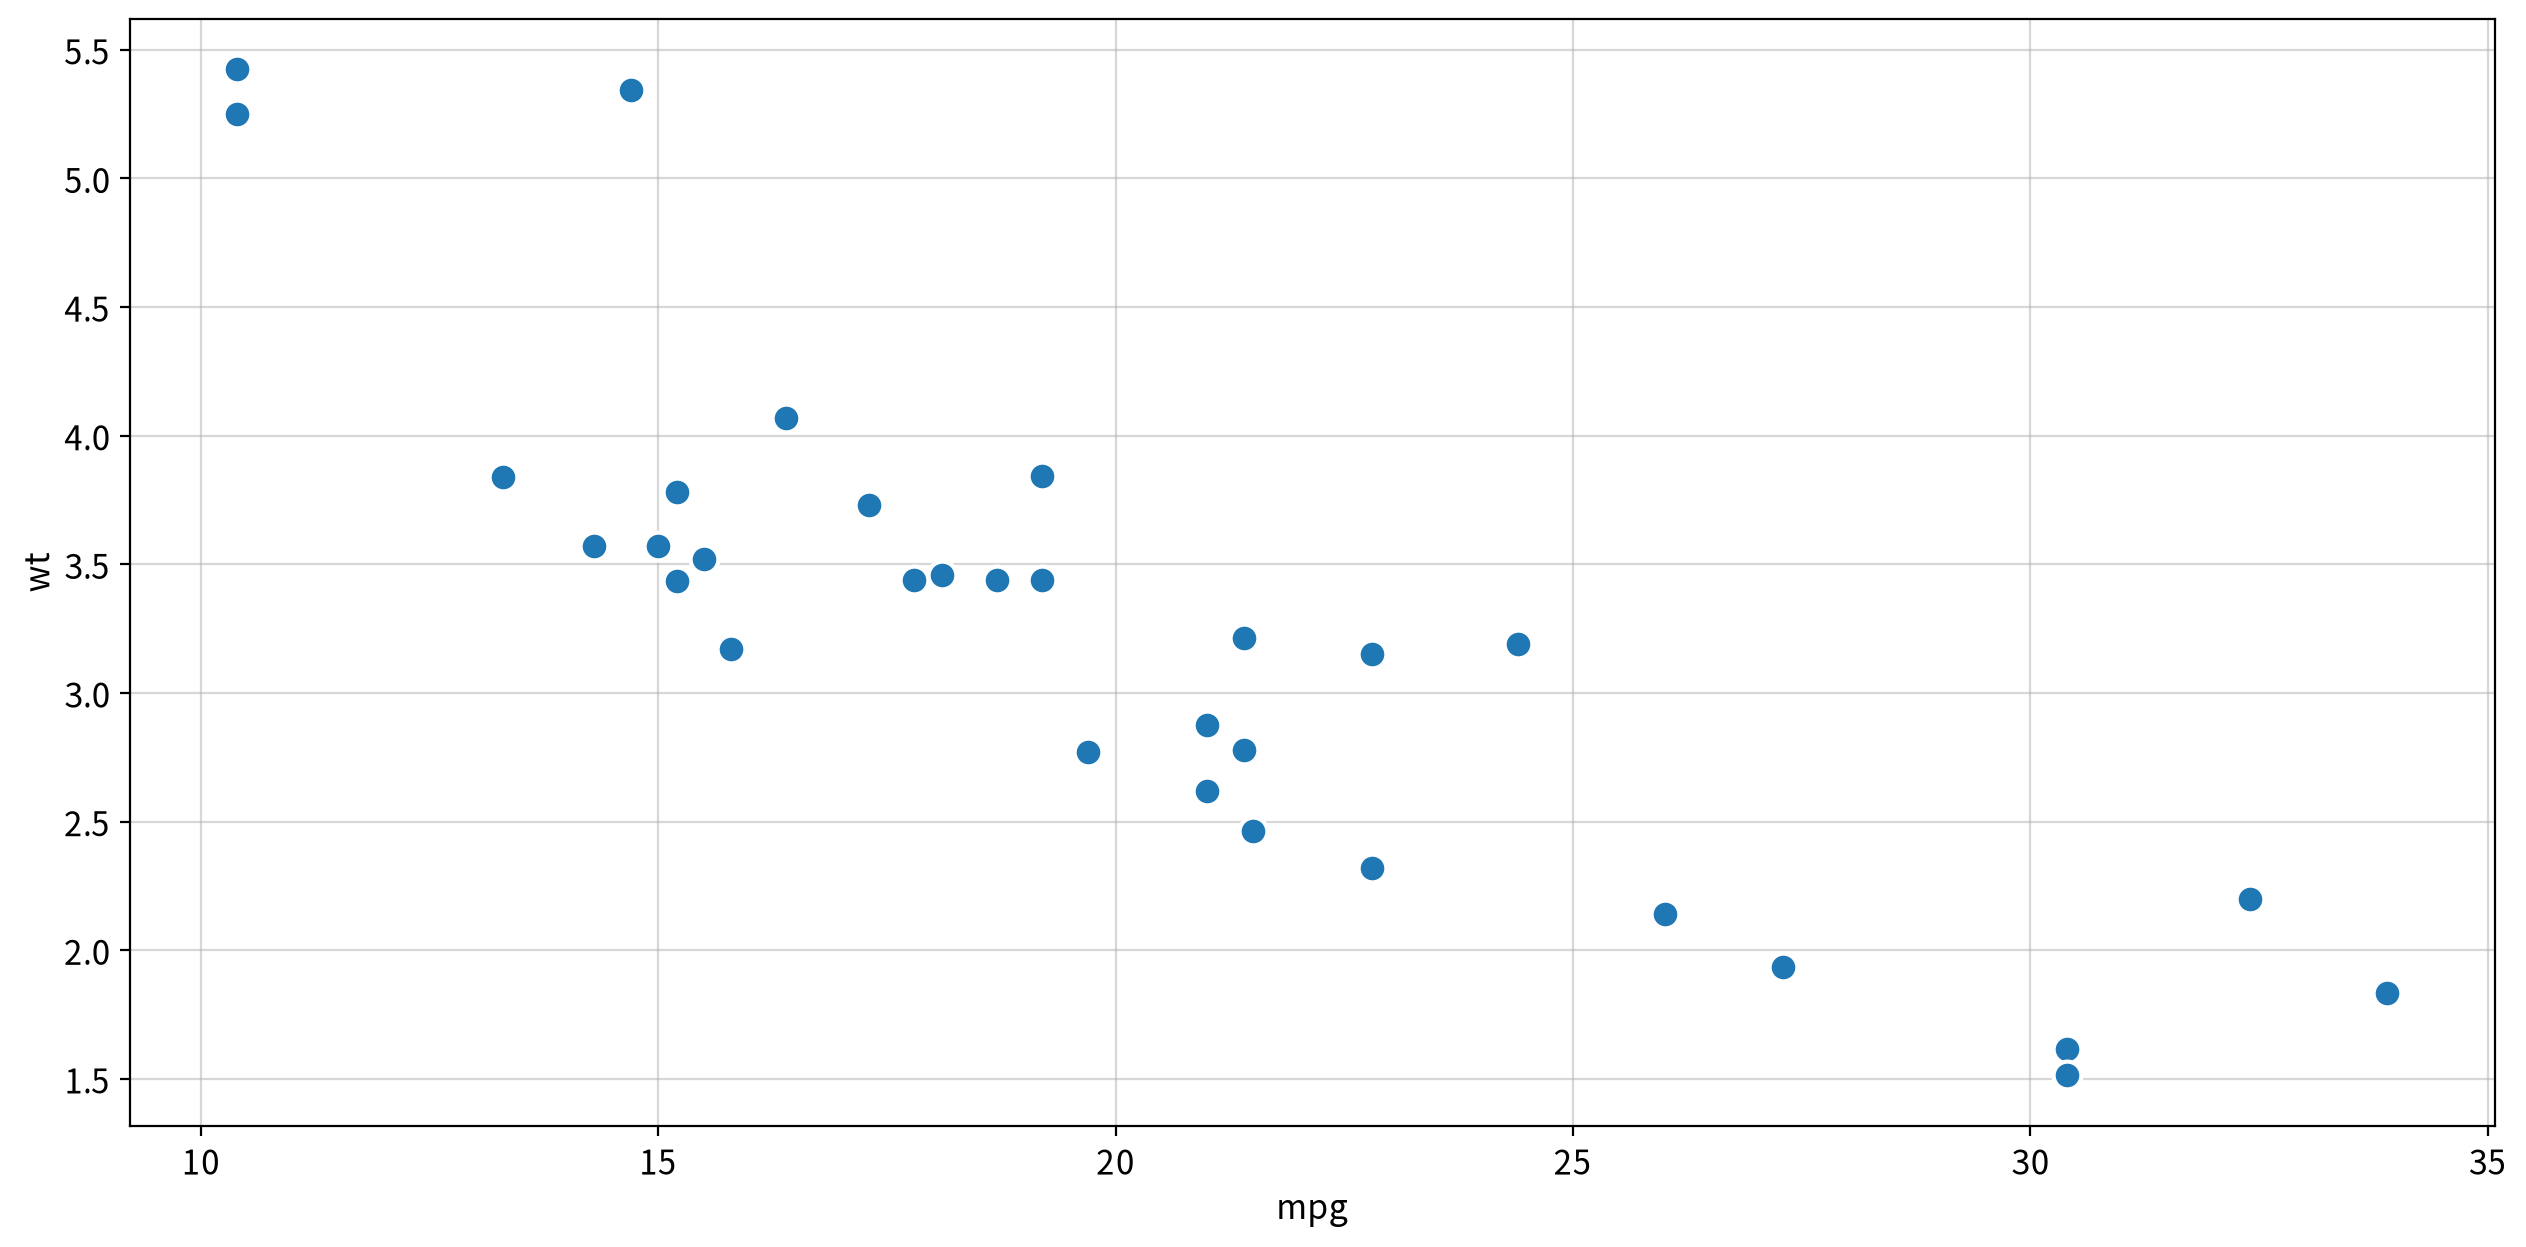

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
mpg,wt,Spearman,-0.886,0.000,Strong,True,True,True,False,False,False


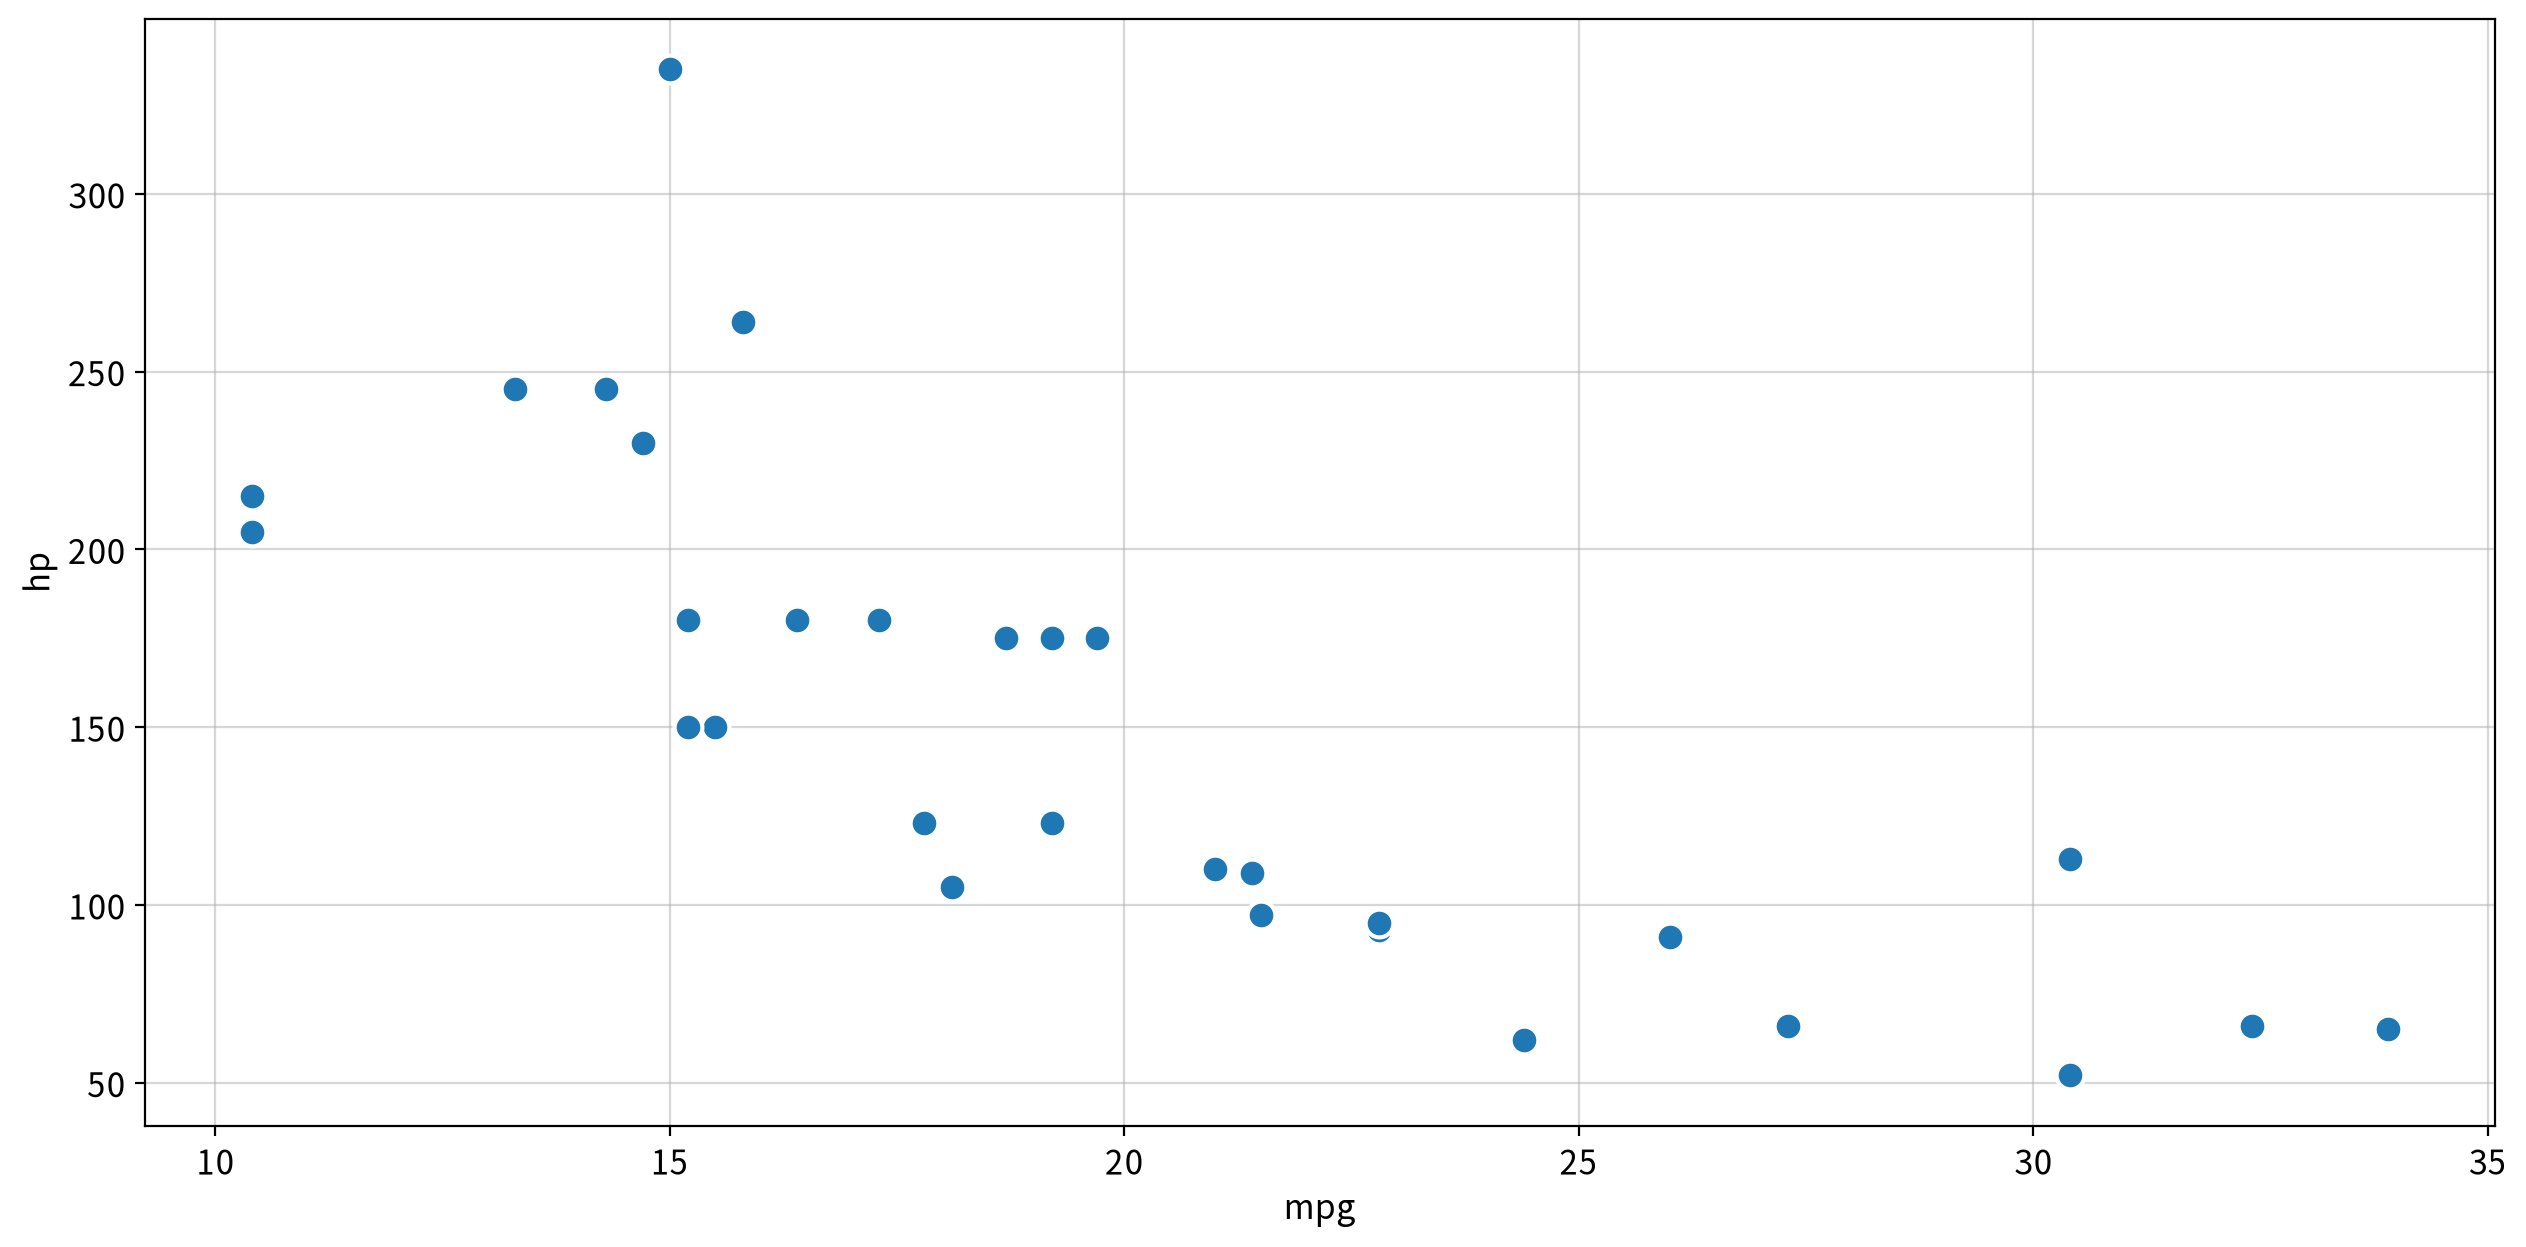

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
mpg,hp,Pearson,-0.776,0.000,Strong,True,True,True,True,False,False


In [6]:
# 연료 효율성(mpg) - 차량 무게(wt)
display(my_stats.correlation(df3, "mpg", "wt"))

# 연료 효율성(mpg) - 마력(hp)
display(my_stats.correlation(df3, "mpg", "hp"))

**답변**

상관분석 함수는 두 변수가 **모두 정규성을 만족하고(normality)** 관계가 **선형(linearity)** 일 때 **Pearson**, 그렇지 않으면 **Spearman** 상관계수를 선택한다.

| 변수 쌍 | 선택된 상관계수 | 상관계수 값 | 선택 이유 |
| --- | --- | --- | --- |
| 연료 효율성(mpg) - 차량 무게(wt) | **Spearman** | -0.886 | 두 변수의 정규성은 만족하나 **선형성을 만족하지 않음(linearity = False)** → Spearman |
| 연료 효율성(mpg) - 마력(hp) | **Pearson** | -0.776 | 정규성과 **선형성을 모두 만족(linearity = True)** → Pearson |

- **mpg - wt** → **Spearman** 상관계수가 선택됨
- **mpg - hp** → **Pearson** 상관계수가 선택됨

#### 2) **연료 효율성 - 배기량**의 상관 강도는 어느 정도 인가?

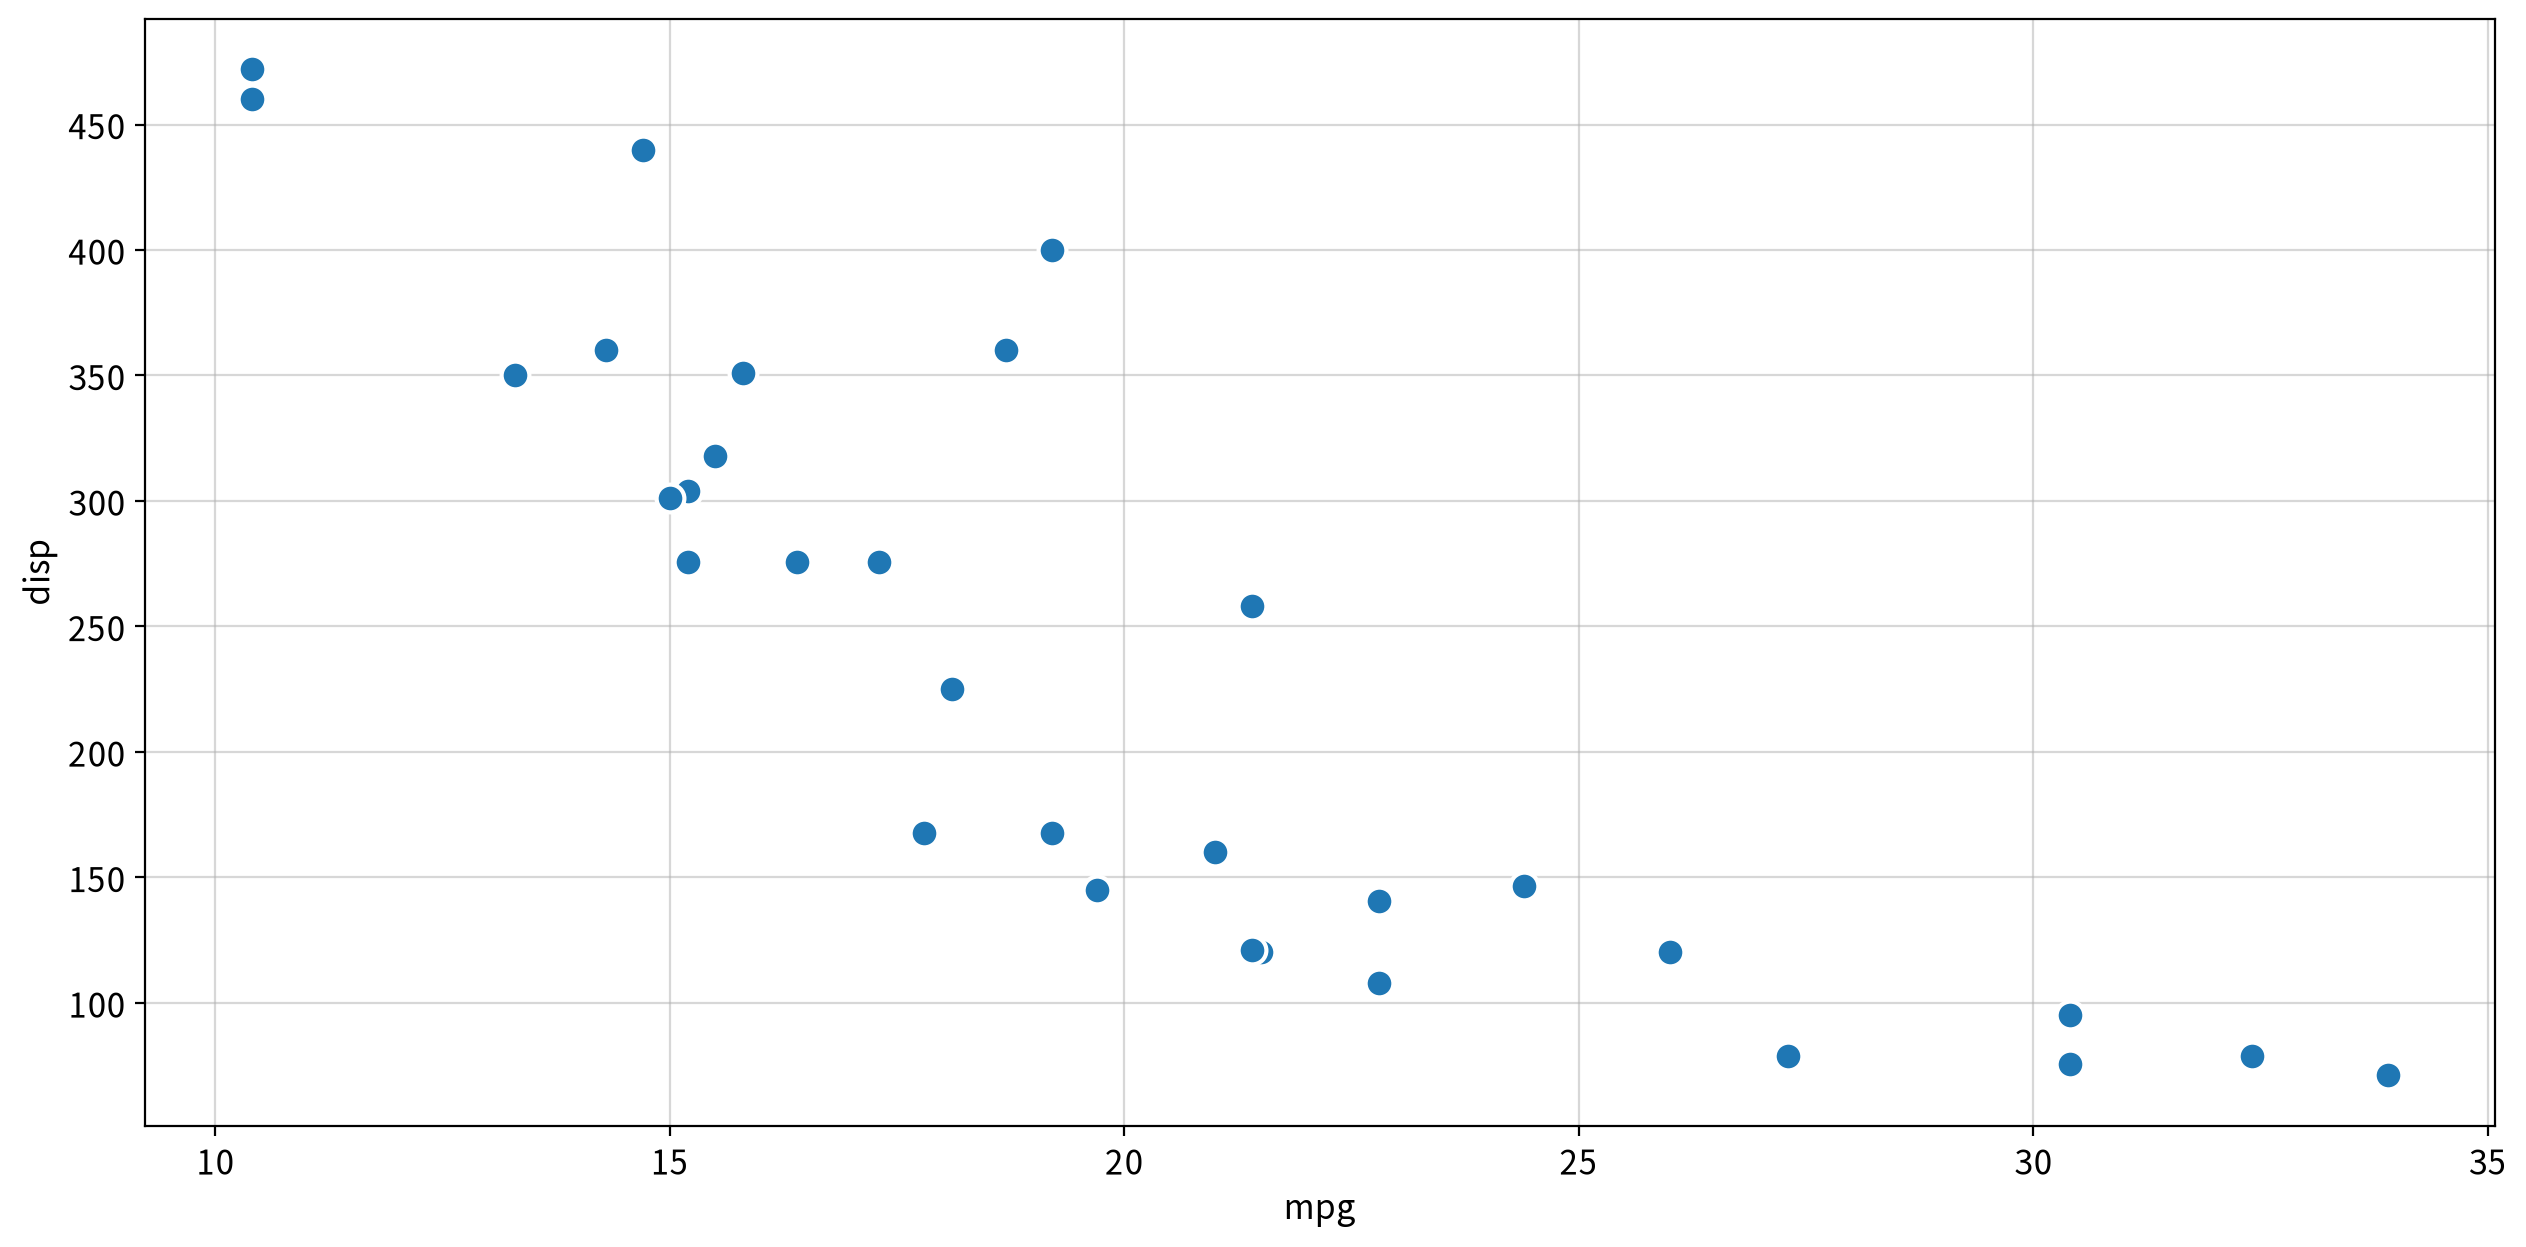

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
mpg,disp,Spearman,-0.909,0.000,Strong,True,True,True,False,False,False


In [7]:
# 연료 효율성(mpg) - 배기량(disp)
my_stats.correlation(df3, "mpg", "disp")

**답변**

연료 효율성(mpg)과 배기량(disp)은 **Spearman 상관계수 -0.909** 로, **강한 음(-)의 상관관계(Strong)** 를 가진다.

- 상관계수의 절대값이 0.7 이상(|-0.909| ≥ 0.7)이므로 상관 강도는 **강함(Strong)** 으로 분류된다.
- p-value가 0.000으로 유의수준 0.05보다 작아 통계적으로 **유의(significant = True)** 하다.
- 부호가 음수이므로 **배기량이 클수록 연료 효율성은 낮아지는** 관계임을 알 수 있다.

#### 3) 가장 강하게 연관되어 있는 속성은 무엇과 무엇인가?

In [8]:
my_stats.multi_correlation(df3, plot=False)

,mpg,disp,hp,drat,wt,qsec
mpg,1.000,-0.909,-0.776,0.681,-0.886,0.419
disp,-0.909,1.000,0.791,-0.684,0.888,-0.434
hp,-0.776,0.791,1.000,-0.520,0.775,-0.708
drat,0.681,-0.684,-0.520,1.000,-0.712,0.091
wt,-0.886,0.888,0.775,-0.712,1.000,-0.225
qsec,0.419,-0.434,-0.708,0.091,-0.225,1.000


method   coef  p-value  strength  significant  normality_x  \
x    y                                                                    
mpg  disp  Spearman -0.909    0.000    Strong         True         True   
     hp     Pearson -0.776    0.000    Strong         True         True   
     drat   Pearson  0.681    0.000  Moderate         True         True   
     wt    Spearman -0.886    0.000    Strong         True         True   
     qsec   Pearson  0.419    0.017  Moderate         True         True   
disp hp     Pearson  0.791    0.000    Strong         True         True   
     drat  Spearman -0.684    0.000  Moderate         True         True   
     wt     Pearson  0.888    0.000    Strong         True         True   
     qsec   Pearson -0.434    0.013  Moderate         True         True   
hp   drat  Spearman -0.520    0.002  Moderate         True         True   
     wt    Spearman  0.775    0.000    Strong         True         True   
     qsec   Pearson -0.708    0.000    Strong         True         True   
drat wt     Pearson -0.712    0.000    Strong         True         True   
     qsec   Pearson  0.091    0.620      Weak        False         True   
wt   qsec  Spearman -0.225    0.215      Weak        False         True   

           normality_y  linearity  influential_outlier  high_skew  
x    y                                                             
mpg  disp         True      False                False      False  
     hp           True       True                False      False  
     drat         True       True                False      False  
     wt           True      False                False      False  
     qsec         True       True                False      False  
disp hp           True       True                False      False  
     drat         True      False                False      False  
     wt           True       True                False      False  
     qsec         True       True                False      False  
hp   drat         True      False                False      False  
     wt           True      False                False      False  
     qsec         True       True                False      False  
drat wt           True       True                False      False  
     qsec         True       True                False      False  
wt   qsec         True       True                 True      False

**답변**

가장 강하게 연관되어 있는 속성은 **연료 효율성(mpg)과 배기량(disp)** 이다.

- 모든 변수 쌍 중 상관계수의 **절대값이 가장 큰 쌍**으로, Spearman 상관계수 **-0.909** (강한 음의 상관)를 가진다.
- 그 다음으로 강한 쌍은 배기량(disp) - 차량 무게(wt) (Pearson 0.888), mpg - wt (Spearman -0.886) 순이다.

#### 4) 서로 상관이 없는 속성의 쌍을 모두 답하시오.

In [9]:
# 모든 변수쌍의 상관분석 결과표를 출력 (산점도 행렬은 Q3에서 확인했으므로 생략)
# 결과표의 significant 열이 False 인 행이 곧 "상관관계가 없는 쌍"
my_stats.multi_correlation(df3, plot=False)

,mpg,disp,hp,drat,wt,qsec
mpg,1.000,-0.909,-0.776,0.681,-0.886,0.419
disp,-0.909,1.000,0.791,-0.684,0.888,-0.434
hp,-0.776,0.791,1.000,-0.520,0.775,-0.708
drat,0.681,-0.684,-0.520,1.000,-0.712,0.091
wt,-0.886,0.888,0.775,-0.712,1.000,-0.225
qsec,0.419,-0.434,-0.708,0.091,-0.225,1.000


method   coef  p-value  strength  significant  normality_x  \
x    y                                                                    
mpg  disp  Spearman -0.909    0.000    Strong         True         True   
     hp     Pearson -0.776    0.000    Strong         True         True   
     drat   Pearson  0.681    0.000  Moderate         True         True   
     wt    Spearman -0.886    0.000    Strong         True         True   
     qsec   Pearson  0.419    0.017  Moderate         True         True   
disp hp     Pearson  0.791    0.000    Strong         True         True   
     drat  Spearman -0.684    0.000  Moderate         True         True   
     wt     Pearson  0.888    0.000    Strong         True         True   
     qsec   Pearson -0.434    0.013  Moderate         True         True   
hp   drat  Spearman -0.520    0.002  Moderate         True         True   
     wt    Spearman  0.775    0.000    Strong         True         True   
     qsec   Pearson -0.708    0.000    Strong         True         True   
drat wt     Pearson -0.712    0.000    Strong         True         True   
     qsec   Pearson  0.091    0.620      Weak        False         True   
wt   qsec  Spearman -0.225    0.215      Weak        False         True   

           normality_y  linearity  influential_outlier  high_skew  
x    y                                                             
mpg  disp         True      False                False      False  
     hp           True       True                False      False  
     drat         True       True                False      False  
     wt           True      False                False      False  
     qsec         True       True                False      False  
disp hp           True       True                False      False  
     drat         True      False                False      False  
     wt           True       True                False      False  
     qsec         True       True                False      False  
hp   drat         True      False                False      False  
     wt           True      False                False      False  
     qsec         True       True                False      False  
drat wt           True       True                False      False  
     qsec         True       True                False      False  
wt   qsec         True       True                 True      False

**답변**

상관분석 결과표에서 **significant(유의성) 열이 False** 인 쌍, 즉 p-value가 유의수준(0.05)보다 커서 통계적으로 상관관계가 없다고 판단되는 쌍은 다음 2개이다.

| 변수 쌍 | 상관계수 | p-value | 판정 |
| --- | --- | --- | --- |
| drat - qsec | 0.091 | 0.620 | Weak / 유의하지 않음 |
| wt - qsec | -0.225 | 0.215 | Weak / 유의하지 않음 |

- **후륜축 비율(drat) - 1/4마일 달성 시간(qsec)**
- **차량 무게(wt) - 1/4마일 달성 시간(qsec)**

두 쌍 모두 p-value > 0.05 이고 상관 강도가 Weak로, **서로 상관이 없는 쌍**이다.

#### 5) 각 변수에 대해 VIF를 계산하고, 기준값(10) 이상인 변수가 몇 개이며 무엇인지 답하시오.

In [10]:
# 각 변수의 VIF(분산팽창계수) 계산
my_stats.compute_vif(df3)

,VIF
wt,10.368
disp,9.324
mpg,6.619
hp,5.565
qsec,3.430
drat,2.534


**답변**

기준값(VIF ≥ 10) 이상인 변수는 **1개**이며, 해당 변수는 **차량 무게(wt, VIF = 10.368)** 이다.

| 변수 | VIF | 기준값(10) 이상 여부 |
| --- | --- | --- |
| **wt** | **10.368** | **O (기준 초과)** |
| disp | 9.324 | X |
| mpg | 6.619 | X |
| hp | 5.565 | X |
| qsec | 3.430 | X |
| drat | 2.534 | X |

- disp(9.324)는 10에 근접하지만 기준값 미만이다.

#### 6) 다중 공선성을 제거하기 위해서 어떤 순서대로 변수를 제거하면 되는지 답하시오.

In [11]:
# VIF가 가장 큰 변수부터 기준값 미만이 될 때까지 하나씩 반복 제거
df3_vif = my_prep.reduce_vif(df3)

[1단계] wt 제거 (VIF = 10.4)

완료! 남은 변수: ['disp', 'drat', 'hp', 'mpg', 'qsec']
최대 VIF = 5.53


**답변**

VIF가 가장 큰 변수부터 기준값(10) 미만이 될 때까지 하나씩 반복 제거한다.

- **[1단계] 차량 무게(wt) 제거** (VIF = 10.4)

wt를 제거한 직후 남은 변수들의 **최대 VIF가 5.53** 으로 기준값(10) 미만이 되었으므로, **추가로 제거할 변수 없이 wt 하나만 제거**하면 된다.

#### 7) 다중 공선성을 제거한 후에 최종적으로 남아 있는 변수는 어떤 것들인지 답하시오.

In [12]:
# 다중 공선성 제거 후 최종적으로 남은 변수
print("남은 변수:", list(df3_vif.columns))
df3_vif.head()

남은 변수: ['mpg', 'cyl', 'disp', 'hp', 'drat', 'qsec', 'vs', 'am', 'gear', 'carb']


,mpg,cyl,disp,hp,drat,qsec,vs,am,gear,carb
name,,,,,,,,,,
Mazda RX4,21.000,6,160.000,110,3.900,16.460,0,1,4,4
Mazda RX4 Wag,21.000,6,160.000,110,3.900,17.020,0,1,4,4
Datsun 710,22.800,4,108.000,93,3.850,18.610,1,1,4,1
Hornet 4 Drive,21.400,6,258.000,110,3.080,19.440,1,0,3,1
Hornet Sportabout,18.700,8,360.000,175,3.150,17.020,0,0,3,2


**답변**

다중 공선성 제거 대상이었던 **연속형(수치형) 변수** 중에서는 wt가 제거되어, 최종적으로 다음 5개가 남는다.

- **mpg, disp, hp, drat, qsec**

VIF 계산 대상이 아니었던 **범주형 변수(cyl, vs, am, gear, carb)** 는 그대로 유지되므로, 최종 데이터프레임에 남는 전체 컬럼은 다음 10개이다.

- **mpg, cyl, disp, hp, drat, qsec, vs, am, gear, carb** (제거된 변수: **wt**)